# Hybrid Equivariant-Transformer (ETN) Canonicalizer + Orthogonal Patch-wise Quantum Vision Transformer

DEEPLENSE 2026 task *Hybrid Quantum-Classical Representation Learning for Dark Matter
Substructure Classification* (3 classes: `no` substructure, `sphere` / CDM, `vort` / axion-vortex).

This notebook fuses **two** ideas from the repo:

```
Image  (3 x H x W, arbitrary orientation / scale)
  |- Equivariant Transformer Network  (Tai, Bailis & Valiant, ICML 2019)
  |     * TransformerSequence of pose predictors: Rotation -> Scale (-> ...)
  |     * each predicts a canonicalizing transform in polar / log-polar coords
  |     * compose -> resample the image into a CANONICAL frame  (continuous SO(2)+scale invariance)
  |- classical CNN feature extractor  (cyclic padding along the periodic angular axis)
  |- patch tokenizer            -> (B, n_tokens, token_dim) tokens
  |- RBS unary data-loader      -> amplitude-encode each token onto its qubit block
  |- butterfly orthogonal layer (shared per token)  -> token-wise 'attention'
  |- cross-token RBS mixing cascade                 -> patch mixing
  |- measure <Z> on all qubits  -> small classical head -> logits
```

**Why this combination for lensing.** Strong-lensing arcs appear at arbitrary position
angle and Einstein-radius scale. The classical e2cnn variant (`qvit_orthogonal_patchwise.ipynb`)
gives *discrete* D4 equivariance; the **ETN canonicalizer used here instead gives continuous
rotation + scale invariance** by warping every image into a learned canonical pose before the
quantum transformer ever sees it. The orthogonal patch-wise QViT (Cherrat et al., *Quantum
Vision Transformers*, 2022; A. Tesi's *Quantum-Transformers*) then provides the quantum
attention inductive bias on the canonicalized tokens.

**Building blocks.** ETN: `EquivariantPosePredictor`, projective `GridTransform`s,
`Rotation`/`Scale`/`RotationScale` transformers, log-polar `coords`. Quantum: the RBS Givens
gate, the unary `vector_loader`, and butterfly / pyramid orthogonal layers.

## 1. Imports

In [1]:
import os
import time
import copy
import collections
import json
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchquantum as tq

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, f1_score,
)
from sklearn.preprocessing import label_binarize

torch.manual_seed(42)
np.random.seed(42)
os.environ["OMP_NUM_THREADS"] = "1"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"TorchQuantum version: {tq.__version__}")
print(f"PyTorch version:      {torch.__version__}")
print(f"CUDA available:       {torch.cuda.is_available()}")
print(f"Device:               {device}")

TorchQuantum version: 0.1.8
PyTorch version:      2.5.1+cu124
CUDA available:       True
Device:               cuda:0


In [2]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import tarfile

CLASS_DIRS = {"axion", "cdm", "no_sub"}

def has_class_folders(root):
    root = Path(root)
    if not root.is_dir():
        return False
    present = {item.name for item in root.iterdir() if item.is_dir()}
    return CLASS_DIRS.issubset(present)

def ensure_gdown():
    if importlib.util.find_spec("gdown") is None:
        print("Installing gdown...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown
    return gdown

def show_dataset_folder(extract_dir):
    print()
    print("Files in dataset folder:")
    for item in sorted(extract_dir.iterdir()):
        print(item.name)

# Google Drive training dataset file
file_id = "11FVLA4IQgeRXx7Dpem14ayb_JCUD0pxX"
url = f"https://drive.google.com/uc?id={file_id}"

base_dir = Path("/home/jovyan/ssh-test-datavol-1")
extract_dir = base_dir / "dataset"
archive_path = base_dir / "data.tar.gz"
required_roots = [extract_dir / "Model_I"]

base_dir.mkdir(parents=True, exist_ok=True)
extract_dir.mkdir(parents=True, exist_ok=True)

if all(has_class_folders(root) for root in required_roots):
    print("Training dataset already extracted. Skipping gdown install, download, and extraction.")
    for root in required_roots:
        print("Found:", root)
else:
    if archive_path.exists() and archive_path.stat().st_size > 0:
        print("Using existing downloaded archive:", archive_path)
    else:
        if archive_path.exists():
            archive_path.unlink()
            print("Deleted empty/partial archive:", archive_path)
        print("Downloading training dataset...")
        gdown = ensure_gdown()
        gdown.download(url, str(archive_path), quiet=False)

    print("Archive path:", archive_path)
    print("File size GB:", round(archive_path.stat().st_size / 1024**3, 3))
    print("Extracting into:", extract_dir)
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_dir)

    print("Extracted to:", extract_dir)
    archive_path.unlink()
    print("Deleted downloaded archive:", archive_path)

    missing = [root for root in required_roots if not has_class_folders(root)]
    if missing:
        raise FileNotFoundError(f"Expected class folders not found after extraction: {missing}")

show_dataset_folder(extract_dir)


Training dataset already extracted. Skipping gdown install, download, and extraction.
Found: /home/jovyan/ssh-test-datavol-1/dataset/Model_I

Files in dataset folder:
Model_I
Model_I_test


In [3]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import tarfile

CLASS_DIRS = {"axion", "cdm", "no_sub"}

def has_class_folders(root):
    root = Path(root)
    if not root.is_dir():
        return False
    present = {item.name for item in root.iterdir() if item.is_dir()}
    return CLASS_DIRS.issubset(present)

def ensure_gdown():
    if importlib.util.find_spec("gdown") is None:
        print("Installing gdown...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown
    return gdown

def show_dataset_folder(extract_dir):
    print()
    print("Files in dataset folder:")
    for item in sorted(extract_dir.iterdir()):
        print(item.name)

# Google Drive test dataset file
file_id = "1Y_q5ene_s0SML3TjRw6sjh8E_SQJD8zU"
url = f"https://drive.google.com/uc?id={file_id}"

base_dir = Path("/home/jovyan/ssh-test-datavol-1")
extract_dir = base_dir / "dataset"
archive_path = base_dir / "testdata.tar.gz"
required_roots = [extract_dir / "Model_I_test"]

base_dir.mkdir(parents=True, exist_ok=True)
extract_dir.mkdir(parents=True, exist_ok=True)

if all(has_class_folders(root) for root in required_roots):
    print("Test dataset already extracted. Skipping gdown install, download, and extraction.")
    for root in required_roots:
        print("Found:", root)
else:
    if archive_path.exists() and archive_path.stat().st_size > 0:
        print("Using existing downloaded archive:", archive_path)
    else:
        if archive_path.exists():
            archive_path.unlink()
            print("Deleted empty/partial archive:", archive_path)
        print("Downloading test dataset...")
        gdown = ensure_gdown()
        gdown.download(url, str(archive_path), quiet=False)

    print("Archive path:", archive_path)
    print("File size GB:", round(archive_path.stat().st_size / 1024**3, 3))
    print("Extracting into:", extract_dir)
    print("This may take time...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_dir)

    print("Extracted to:", extract_dir)
    archive_path.unlink()
    print("Deleted downloaded archive:", archive_path)

    missing = [root for root in required_roots if not has_class_folders(root)]
    if missing:
        raise FileNotFoundError(f"Expected class folders not found after extraction: {missing}")

show_dataset_folder(extract_dir)


Test dataset already extracted. Skipping gdown install, download, and extraction.
Found: /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test

Files in dataset folder:
Model_I
Model_I_test


## 2. Configuration and dataset paths

In [4]:
# Data paths - UPDATE THESE
NOTEBOOK_NAME = "etn_qvit_hybrid"
# Change this string to model_1/model_2/model_3/model_4 when changing data paths.
DATASET_ID = "model_1"
DATASET_ID = os.environ.get("DEEPLENSE_DATASET_ID", DATASET_ID)

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "README.md").exists() and (path / "notebooks").exists():
            return path
    return start

def slugify(value):
    value = str(value).strip().lower()
    slug = "".join(ch if ch.isalnum() else "_" for ch in value)
    slug = "_".join(part for part in slug.split("_") if part)
    return slug or "model_1"

DATASET_ID = slugify(DATASET_ID)
VALID_DATASET_IDS = {f"model_{i}" for i in range(1, 5)}
if DATASET_ID not in VALID_DATASET_IDS:
    raise ValueError(f"DATASET_ID must be one of {sorted(VALID_DATASET_IDS)}, got {DATASET_ID!r}")

DATASET_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV",
}
TEST_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I_test",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II_test",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III_test",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV_test",
}
DATA_ROOT = os.environ.get("DEEPLENSE_DATA_ROOT", DATASET_ROOTS[DATASET_ID])
TEST_DIR = os.environ.get("DEEPLENSE_TEST_DIR", TEST_ROOTS[DATASET_ID])
VAL_SPLIT = float(os.environ.get("DEEPLENSE_VAL_SPLIT", "0.20"))
if not 0.0 < VAL_SPLIT < 1.0:
    raise ValueError(f"VAL_SPLIT must be between 0 and 1, got {VAL_SPLIT}")

# DataLoader performance knobs. This mirrors the faster equiqnn notebook and avoids
# pre-caching the full dataset on the GPU before training starts.
CACHE_DATA_IN_MEMORY = os.environ.get("DEEPLENSE_CACHE_DATA", "1") != "0"
NUM_WORKERS = int(os.environ.get("DEEPLENSE_NUM_WORKERS", str(min(4, os.cpu_count() or 0))))
PREFETCH_FACTOR = int(os.environ.get("DEEPLENSE_PREFETCH_FACTOR", "4"))
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

PROJECT_ROOT = find_project_root()
CLASSIFICATION_RUN_DIR = PROJECT_ROOT / "notebooks" / "equivariant" / NOTEBOOK_NAME / DATASET_ID
RESULTS_DIR = CLASSIFICATION_RUN_DIR / "results"
CHECKPOINT_DIR = CLASSIFICATION_RUN_DIR / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"best_{NOTEBOOK_NAME}_{DATASET_ID}.pth"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RUN_METADATA_PATH = CLASSIFICATION_RUN_DIR / "run_metadata.json"

CFG: Dict[str, Any] = {
    # Data
    "seed": 42,
    "resize_to": 128,
    "in_channels": 3,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std":  [0.229, 0.224, 0.225],
    "batch_size": 64,
    "val_split": VAL_SPLIT,
    "use_augmentation": True,
    "cache_data_in_memory": CACHE_DATA_IN_MEMORY,
    "num_workers": NUM_WORKERS,
    "prefetch_factor": PREFETCH_FACTOR,
    "pin_memory": PIN_MEMORY,
    "class_names": None,  # inferred from DATA_ROOT folders

    # Equivariant Transformer Network (canonicalizer front-end)
    "etn_transformers": ["Rotation", "Scale"],  # composed in order; pose predicted in canonical coords
    "etn_equivariant": True,                      # EquivariantPosePredictor (vs DirectPosePredictor)
    "etn_nf": 32,                                  # pose-predictor channels
    "etn_kernel_size": 3,
    "etn_out_coords": "logpolar_grid",             # coord system for the final classification resample
    "etn_out_size": 96,                            # canonical image resample resolution

    # Classical CNN feature extractor (over the canonicalized image)
    "cnn_nf": 32,
    "dropout_rate": 0.3,

    # Orthogonal patch-wise QViT
    "n_tokens": 8,                 # number of patch tokens fed to the quantum transformer
    "token_dim": 2,                # qubits per token block (power of 2); unary loader dim
    "n_qubits": 16,                # = n_tokens * token_dim  (KEEP <= ~18; 8x4=32 qubits is infeasible on a statevector sim)
    "n_orth_layers": 2,            # stacked orthogonal-attention layers
    "num_classes": 3,

    # Training
    "lr": 2e-3,
    "weight_decay": 1e-5,
    "num_epochs": 50,
    "patience": 12,
    "warmup_epochs": 2,
    "grad_clip": 1.0,
}


RUN_METADATA_PATH = CLASSIFICATION_RUN_DIR / "run_metadata.json"
with RUN_METADATA_PATH.open("w") as f:
    json.dump({
        "notebook_name": NOTEBOOK_NAME,
        "dataset_id": DATASET_ID,
        "data_root": str(DATA_ROOT),
        "test_dir": str(TEST_DIR),
        "val_split": VAL_SPLIT,
        "run_dir": str(CLASSIFICATION_RUN_DIR),
        "results_dir": str(RESULTS_DIR),
        "checkpoint_path": str(CHECKPOINT_PATH),
        "config": CFG,
    }, f, indent=2)

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"TEST_DIR:  {TEST_DIR}")
print(f"VAL_SPLIT: {VAL_SPLIT:.2f}")
print(f"Dataset/run id: {DATASET_ID}")
print(f"Run directory: {CLASSIFICATION_RUN_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")
print(f"Run metadata: {RUN_METADATA_PATH}")
print(f"Image:     {CFG['resize_to']}x{CFG['resize_to']}  classes=auto from DATA_ROOT folders")
print(f"ETN:       {CFG['etn_transformers']} -> {CFG['etn_out_coords']} @ {CFG['etn_out_size']}px")
print(f"Quantum:   {CFG['n_tokens']} tokens x {CFG['token_dim']} dim = {CFG['n_qubits']} qubits")
print(f"Cache in RAM: {CACHE_DATA_IN_MEMORY}")
print(f"DataLoader workers: {NUM_WORKERS}, prefetch_factor={PREFETCH_FACTOR}, pin_memory={PIN_MEMORY}")


DATA_ROOT: /home/jovyan/ssh-test-datavol-1/dataset/Model_I
TEST_DIR:  /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test
VAL_SPLIT: 0.20
Dataset/run id: model_1
Run directory: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/etn_qvit_hybrid/model_1
Results directory: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/etn_qvit_hybrid/model_1/results
Checkpoint path: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/etn_qvit_hybrid/model_1/checkpoints/best_etn_qvit_hybrid_model_1.pth
Run metadata: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/etn_qvit_hybrid/model_1/run_metadata.json
Image:     128x128  classes=auto from DATA_ROOT folders
ETN:       ['Rotation', 'Scale'] -> logpolar_grid @ 96px
Quantum:   8 tokens x 2 dim = 16 qubits
Cache in RAM: True
DataLoader workers: 4, prefetch_factor=4, pin_memory=True


## 3. Multi-worker pinned-memory dataset pipeline

This uses the same `NPYImageFolder` + PyTorch `DataLoader` pattern as the faster
notebooks. It avoids the previous `build_gpu_cache` startup path that loaded,
resized, normalized, and stored every train/test sample on the GPU before training
could begin.


In [5]:
IMAGE_KEYS = ("image", "img", "x", "data", "array", "arr", "lens", "sample")


def extract_image_array(value):
    """Return the image array from raw .npy content, including object arrays."""
    if isinstance(value, np.ndarray):
        if value.dtype == object:
            if value.ndim == 0:
                return extract_image_array(value.item())
            for item in value.reshape(-1):
                try:
                    candidate = extract_image_array(item)
                    if np.asarray(candidate).ndim >= 2:
                        return candidate
                except Exception:
                    continue
            return np.asarray(value.tolist())
        return value

    if isinstance(value, dict):
        for key in IMAGE_KEYS:
            if key in value:
                return extract_image_array(value[key])
        for item in value.values():
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        raise ValueError("Could not find an image-like array in .npy dict")

    if isinstance(value, (list, tuple)):
        for item in value:
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        return np.asarray(value)

    return np.asarray(value)


def load_npy_image(filepath):
    raw = np.load(filepath, allow_pickle=True)
    arr = np.asarray(extract_image_array(raw))
    if arr.dtype == object:
        arr = np.asarray(extract_image_array(arr), dtype=np.float32)
    else:
        arr = arr.astype(np.float32, copy=False)

    arr = np.squeeze(arr)
    if arr.ndim == 2:
        arr = arr[np.newaxis, :, :]
    elif arr.ndim == 3:
        if arr.shape[0] not in (1, 3):
            arr = arr.transpose(2, 0, 1)
    else:
        raise ValueError(f"Expected a 2D or 3D image array from {filepath}, got shape {arr.shape}")

    if arr.size == 0:
        raise ValueError(f"Empty image array in {filepath}")

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr_max = float(np.max(arr))
    if arr_max > 1.0:
        arr = arr / arr_max
    return arr.astype(np.float32, copy=False)


class NPYImageFolder(Dataset):
    """Dataset loader for .npy image files organized in class folders."""

    def __init__(self, root_dir, transform=None, samples=None, classes=None, class_to_idx=None, cache=False):
        self.root_dir = str(root_dir)
        self.transform = transform
        self.cache = None
        if not os.path.isdir(self.root_dir):
            raise FileNotFoundError(
                f"Dataset directory not found: {self.root_dir}\n"
                "Expected class folders like axion/, cdm/, no_sub/."
            )

        self.classes = list(classes) if classes is not None else sorted(
            d for d in os.listdir(self.root_dir)
            if os.path.isdir(os.path.join(self.root_dir, d))
        )
        self.class_to_idx = dict(class_to_idx) if class_to_idx is not None else {
            cls: idx for idx, cls in enumerate(self.classes)
        }

        if samples is None:
            self.samples = []
            for class_name in self.classes:
                class_dir = os.path.join(self.root_dir, class_name)
                for filename in sorted(os.listdir(class_dir)):
                    if filename.endswith(".npy"):
                        filepath = os.path.join(class_dir, filename)
                        self.samples.append((filepath, self.class_to_idx[class_name]))
        else:
            self.samples = list(samples)

        if not self.samples:
            raise RuntimeError(f"No .npy files found under {self.root_dir}")

        self.labels = torch.tensor([label for _, label in self.samples], dtype=torch.long)

        print(f"Found {len(self.samples)} samples in {self.root_dir}")
        print(f"Classes: {self.classes}")

        if cache:
            desc = f"cache {Path(self.root_dir).name}"
            print(f"Caching {len(self.samples)} decoded samples from {self.root_dir} in RAM...")
            self.cache = [
                torch.from_numpy(np.ascontiguousarray(load_npy_image(filepath))).float()
                for filepath, _ in tqdm(self.samples, desc=desc, leave=False)
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        if self.cache is None:
            arr = load_npy_image(filepath)
            tensor = torch.from_numpy(np.ascontiguousarray(arr)).float()
        else:
            tensor = self.cache[idx]

        if self.transform:
            tensor = self.transform(tensor)

        return tensor, label


class NPYTransform:
    """Resize, channel-match, and normalize NPY tensors for the ETN-QViT model."""

    def __init__(self, img_size, mean, std, in_channels=3):
        self.img_size = img_size
        self.in_channels = in_channels
        self.mean = torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(-1, 1, 1)

    def __call__(self, x):
        if x.shape[0] == 1 and self.in_channels == 3:
            x = x.repeat(3, 1, 1)
        elif x.shape[0] == 3 and self.in_channels == 1:
            x = x.mean(dim=0, keepdim=True)
        elif x.shape[0] != self.in_channels:
            x = x[:self.in_channels]

        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(
                x.unsqueeze(0), size=(self.img_size, self.img_size),
                mode="bilinear", align_corners=False,
            ).squeeze(0)

        if self.mean.numel() == x.shape[0]:
            x = (x - self.mean) / self.std
        return x


class GPUAugment(nn.Module):
    """On-the-fly D4 augmentation on the current training batch."""

    def __init__(self, p_hflip: float = 0.5, p_vflip: float = 0.5, p_rot90: float = 0.75):
        super().__init__()
        self.p_hflip = p_hflip
        self.p_vflip = p_vflip
        self.p_rot90 = p_rot90

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b = x.shape[0]
        dev = x.device
        m = (torch.rand(b, device=dev) < self.p_hflip).view(b, 1, 1, 1)
        x = torch.where(m, x.flip(-1), x)
        m = (torch.rand(b, device=dev) < self.p_vflip).view(b, 1, 1, 1)
        x = torch.where(m, x.flip(-2), x)
        if torch.rand(1, device=dev).item() < self.p_rot90:
            k = int(torch.randint(1, 4, (1,), device=dev).item())
            x = torch.rot90(x, k, dims=[-2, -1])
        return x


def stratified_train_val_samples(samples, val_split=0.20, seed=42):
    """Split a single class-folder dataset into train/val while preserving each class."""
    labels = np.array([label for _, label in samples])
    rng = np.random.default_rng(seed)
    train_indices, val_indices = [], []

    for class_id in sorted(np.unique(labels).tolist()):
        class_indices = np.where(labels == class_id)[0]
        rng.shuffle(class_indices)
        if len(class_indices) <= 1:
            n_val = 0
        else:
            n_val = max(1, int(round(len(class_indices) * val_split)))
            n_val = min(n_val, len(class_indices) - 1)
        val_indices.extend(class_indices[:n_val].tolist())
        train_indices.extend(class_indices[n_val:].tolist())

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    train_samples = [samples[i] for i in train_indices]
    val_samples = [samples[i] for i in val_indices]
    if not train_samples or not val_samples:
        raise ValueError("Train/val split is empty. Check VAL_SPLIT and per-class sample counts.")
    return train_samples, val_samples


def make_dataloader(dataset, batch_size, shuffle):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = PREFETCH_FACTOR
    return DataLoader(dataset, **kwargs)


def build_loaders(cfg: Dict[str, Any]):
    t0 = time.time()
    transform = NPYTransform(
        cfg["resize_to"], cfg["imagenet_mean"], cfg["imagenet_std"],
        in_channels=cfg["in_channels"],
    )
    cache_data = bool(cfg.get("cache_data_in_memory", CACHE_DATA_IN_MEMORY))

    full_dataset = NPYImageFolder(DATA_ROOT, transform=None, cache=False)
    train_samples, val_samples = stratified_train_val_samples(
        full_dataset.samples, val_split=cfg["val_split"], seed=cfg["seed"]
    )
    train_set = NPYImageFolder(
        DATA_ROOT, transform, samples=train_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx,
        cache=cache_data,
    )
    val_set = NPYImageFolder(
        DATA_ROOT, transform, samples=val_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx,
        cache=cache_data,
    )
    test_set = NPYImageFolder(TEST_DIR, transform, cache=cache_data)

    if test_set.classes != full_dataset.classes:
        raise ValueError(
            f"Class folders differ between DATA_ROOT and TEST_DIR: "
            f"{full_dataset.classes} vs {test_set.classes}"
        )

    expected_classes = cfg.get("class_names")
    if expected_classes is not None:
        assert full_dataset.classes == expected_classes, f"class mismatch: {full_dataset.classes} vs {expected_classes}"

    train_loader = make_dataloader(train_set, batch_size=cfg["batch_size"], shuffle=True)
    val_loader = make_dataloader(val_set, batch_size=cfg["batch_size"], shuffle=False)
    test_loader = make_dataloader(test_set, batch_size=cfg["batch_size"], shuffle=False)
    augmenter = GPUAugment().to(device) if cfg["use_augmentation"] else None

    counts = collections.Counter(train_set.labels.tolist())
    print(f"Loader build took {time.time() - t0:.1f}s")
    print(f"Sizes: train={len(train_set)} val={len(val_set)} test={len(test_set)}")
    print("Class counts (train):", {full_dataset.classes[k]: v for k, v in sorted(counts.items())})
    print(f"Cache in RAM: {'ON' if cache_data else 'OFF'}")
    print(f"DataLoader workers: {NUM_WORKERS}, pin_memory={PIN_MEMORY}")
    print(f"GPUAugment: {'ON' if augmenter is not None else 'OFF'}")
    return train_loader, val_loader, test_loader, augmenter, full_dataset.classes


In [6]:
train_loader, val_loader, test_loader, augmenter, CLASS_NAMES = build_loaders(CFG)


Found 87525 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Found 70021 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Caching 70021 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I in RAM...


Found 17504 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Caching 17504 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I in RAM...


Found 15000 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test
Classes: ['axion', 'cdm', 'no_sub']
Caching 15000 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test in RAM...


Loader build took 124.4s
Sizes: train=70021 val=17504 test=15000
Class counts (train): {'axion': 23118, 'cdm': 23818, 'no_sub': 23085}
Cache in RAM: ON
DataLoader workers: 4, pin_memory=True
GPUAugment: ON


## 4. Data visualization

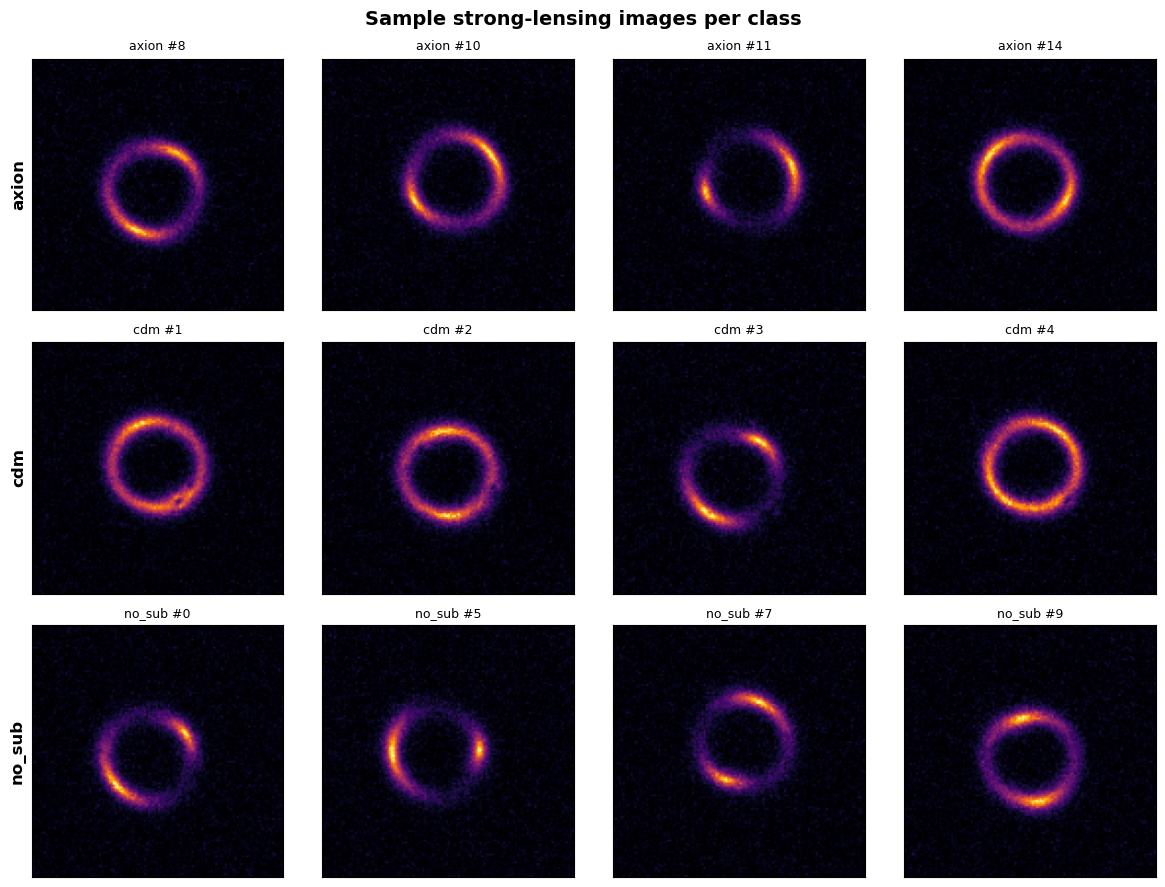

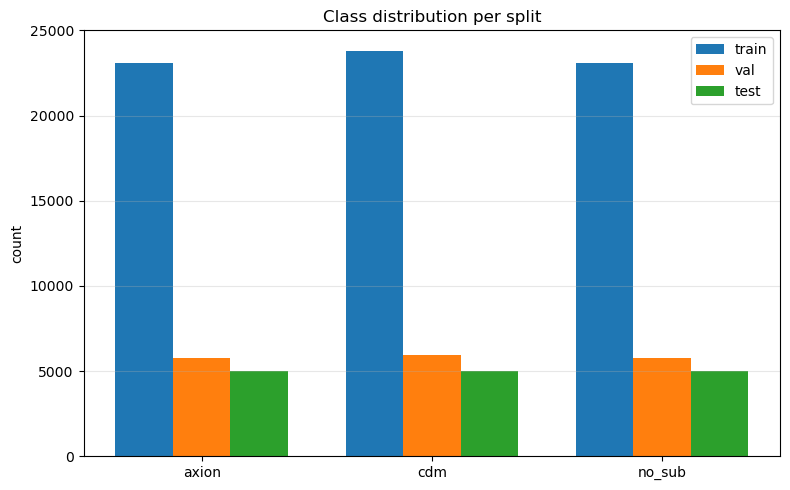

train: {'axion': 23118, 'cdm': 23818, 'no_sub': 23085}
val:   {'axion': 5779, 'cdm': 5954, 'no_sub': 5771}
test:  {'axion': 5000, 'cdm': 5000, 'no_sub': 5000}


In [7]:
_mean = torch.tensor(CFG["imagenet_mean"]).view(3, 1, 1)
_std = torch.tensor(CFG["imagenet_std"]).view(3, 1, 1)


def _denorm(img_chw: torch.Tensor) -> np.ndarray:
    img = img_chw.detach().cpu().float() * _std + _mean
    return img.clamp(0, 1)[0].numpy()


def _labels(ds) -> np.ndarray:
    return ds.labels.detach().cpu().numpy()


def _counts(ds) -> list:
    lab = _labels(ds)
    return [int((lab == i).sum()) for i in range(len(CLASS_NAMES))]


n_per_class = 4
fig, axes = plt.subplots(len(CLASS_NAMES), n_per_class,
                         figsize=(3 * n_per_class, 3 * len(CLASS_NAMES)))
train_ds = train_loader.dataset
train_lab = _labels(train_ds)
for r, cname in enumerate(CLASS_NAMES):
    idxs = np.where(train_lab == r)[0][:n_per_class]
    for col in range(n_per_class):
        ax = axes[r, col]
        if col < len(idxs):
            sidx = int(idxs[col])
            img, _ = train_ds[sidx]
            ax.imshow(_denorm(img), cmap="inferno")
            ax.set_title(f"{cname} #{sidx}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(cname, fontsize=12, fontweight="bold")
plt.suptitle("Sample strong-lensing images per class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "etn_qvit_data_samples.png", dpi=150, bbox_inches="tight")
plt.show()

train_c = _counts(train_loader.dataset)
val_c = _counts(val_loader.dataset)
test_c = _counts(test_loader.dataset)

xpos = np.arange(len(CLASS_NAMES)); w = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(xpos - w, train_c, w, label="train")
ax.bar(xpos,     val_c,   w, label="val")
ax.bar(xpos + w, test_c,  w, label="test")
ax.set_xticks(xpos); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("count"); ax.set_title("Class distribution per split")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "etn_qvit_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("train:", dict(zip(CLASS_NAMES, train_c)))
print("val:  ", dict(zip(CLASS_NAMES, val_c)))
print("test: ", dict(zip(CLASS_NAMES, test_c)))


## 5. Equivariant Transformer Network (ETN) canonicalizer

Faithful, self-contained re-implementation of the ETN building blocks from
`GSoC-23/models/equivariant_transformers` (Tai, Bailis & Valiant, *Equivariant Transformer
Networks*, ICML 2019).

### 5.1 Canonical coordinate systems and projective grid transforms
Each transformer predicts a pose parameter in a coordinate system where the target symmetry
acts as a **translation** (rotation -> angle in polar coords; scale -> radius in log-polar
coords), so a translation-equivariant CNN can read it off equivariantly.

In [8]:
def identity_grid(output_size, ulim=(-1, 1), vlim=(-1, 1), device=None):
    nv, nu = output_size
    urange = torch.linspace(ulim[0], ulim[1], nu, device=device)
    vrange = torch.linspace(vlim[0], vlim[1], nv, device=device)
    vs, us = torch.meshgrid([vrange, urange], indexing="ij")
    return torch.stack([us, vs], 2)


def polar_grid(output_size, ulim=(0, np.sqrt(2.)), vlim=(-np.pi, np.pi), device=None):
    nv, nu = output_size
    urange = torch.linspace(ulim[0], ulim[1], nu, device=device)
    vrange = torch.linspace(vlim[0], vlim[1], nv, device=device)
    vs, us = torch.meshgrid([vrange, urange], indexing="ij")
    return torch.stack([us * torch.cos(vs), us * torch.sin(vs)], 2)


def logpolar_grid(output_size, ulim=(None, np.log(2.) / 2.), vlim=(-np.pi, np.pi), device=None):
    nv, nu = output_size
    if ulim[0] is None:
        ulim = (-np.log(nu), ulim[1])
    urange = torch.linspace(ulim[0], ulim[1], nu, device=device)
    vrange = torch.linspace(vlim[0], vlim[1], nv, device=device)
    vs, us = torch.meshgrid([vrange, urange], indexing="ij")
    rs = torch.exp(us)
    return torch.stack([rs * torch.cos(vs), rs * torch.sin(vs)], 2)


COORD_FNS = {
    "identity_grid": identity_grid,
    "polar_grid": polar_grid,
    "logpolar_grid": logpolar_grid,
}


class GridTransform(object):
    """A grid-to-grid transformation (callable on [B, H, W, 2] coordinate tensors)."""

    def __init__(self, transform):
        self.transform = transform

    def __call__(self, grid):
        return self.transform(grid)

    def compose(self, other):
        if not isinstance(other, GridTransform):
            raise ValueError("Invalid type")
        return GridTransform(lambda x: self(other(x)))


class ProjectiveGridTransform(GridTransform):
    """A batched 3x3 projective grid transform."""

    def __init__(self, transform):
        super().__init__(transform)

    def __call__(self, grid):
        n, h, w, _ = grid.shape
        ones = grid.new_ones(n, h, w, 1)
        coords = torch.cat([grid, ones], -1)
        coords = torch.bmm(coords.view(n, h * w, 3), self.transform.permute(0, 2, 1))
        coords = coords.view(n, h, w, 3)
        grid_tf = torch.empty_like(grid)
        grid_tf[:, :, :, 0] = coords[:, :, :, 0].div(coords[:, :, :, 2] + 1e-8)
        grid_tf[:, :, :, 1] = coords[:, :, :, 1].div(coords[:, :, :, 2] + 1e-8)
        return grid_tf

    def compose(self, other):
        if isinstance(other, ProjectiveGridTransform):
            return ProjectiveGridTransform(torch.bmm(self.transform, other.transform))
        elif isinstance(other, GridTransform):
            return super().compose(other)
        raise ValueError("Invalid type")


### 5.2 Equivariant pose predictor and transformer modules
`EquivariantPosePredictor` is a small translation-equivariant CNN that, in a periodic
coordinate system, produces a 1-D heat-map whose **centroid** is the predicted pose. Cyclic
padding handles the periodic angular axis. `Transformer` resamples the input into the
canonical coords, predicts a pose, and returns the corresponding `ProjectiveGridTransform`.

In [9]:
def _cyclic_pad(x, pad, axis):
    if isinstance(pad, int):
        pad = (pad, pad)
    if pad[0] == 0 and pad[1] == 0:
        return x
    parts = []
    if pad[0] > 0:
        parts.append(x.narrow(axis, x.shape[axis] - pad[0], pad[0]))
    parts.append(x)
    if pad[1] > 0:
        parts.append(x.narrow(axis, 0, pad[1]))
    return torch.cat(parts, axis)


def _pad1d(x, pad, mode):
    if mode == "cyclic":
        return _cyclic_pad(x, pad=pad, axis=2)
    if mode is not None:
        return F.pad(x, (pad, pad), mode)
    return x


def _pad2d(x, pad, mode):
    if isinstance(pad, int):
        pad = (pad, pad)
    if isinstance(mode, str):
        mode = (mode, mode)
    wmode, hmode = mode
    wpad, hpad = pad
    out = x
    if wmode == "cyclic":
        out = _cyclic_pad(out, pad=wpad, axis=3)
    elif wmode is not None:
        out = F.pad(out, (wpad, wpad, 0, 0), wmode)
    if hmode == "cyclic":
        out = _cyclic_pad(out, pad=hpad, axis=2)
    elif hmode is not None:
        out = F.pad(out, (0, 0, hpad, hpad), hmode)
    return out


def _centroid(heatmap, step, periodic=False):
    rnge = torch.arange(heatmap.shape[1], dtype=torch.float, device=heatmap.device).mul_(step)
    rnge.add_(-rnge[-1] / 2)
    if periodic:
        thetas = rnge.mul_(np.pi)
        x_c = heatmap.mv(torch.cos(thetas))
        y_c = heatmap.mv(torch.sin(thetas))
        return torch.atan2(y_c, x_c).div(np.pi)
    return heatmap.mv(rnge)


class EquivariantPosePredictor(nn.Module):
    """Translation-equivariant CNN predicting pose parameters via heat-map centroids."""

    def __init__(self, in_channels, nf, kernel_size=5, strides=(2, 2),
                 periodic_u=False, periodic_v=False, return_u=True, return_v=True,
                 nonlin=lambda x: F.leaky_relu(x, 0.1, True), **kwargs):
        super().__init__()
        if not return_u and not return_v:
            raise ValueError("At least one of return_u and return_v must be true.")
        self.return_u, self.return_v = return_u, return_v
        self.periodic_u, self.periodic_v = periodic_u, periodic_v
        self.nonlin = nonlin
        self.pad_mode = ("cyclic" if periodic_u else "constant",
                         "cyclic" if periodic_v else "constant")
        k = kernel_size
        self.conv1 = nn.Conv2d(in_channels, nf, k, stride=strides[0], bias=False)
        self.bn1 = nn.BatchNorm2d(nf)
        self.conv2 = nn.Conv2d(nf, nf, k, stride=strides[1], bias=False)
        self.bn2 = nn.BatchNorm2d(nf)
        self.conv_u = nn.Conv1d(nf, 1, k, stride=1, bias=False)
        self.conv_v = nn.Conv1d(nf, 1, k, stride=1, bias=False)
        self.bias_u = nn.Parameter(torch.tensor(0.))
        self.bias_v = nn.Parameter(torch.tensor(0.))

    @staticmethod
    def _forward(x, module, deltas):
        vstride, ustride = module.stride
        vdelta, udelta = deltas
        return module(x), (vdelta * vstride, udelta * ustride)

    def forward(self, x):
        vdelta, udelta = 2. / (x.shape[2] - 1), 2. / (x.shape[3] - 1)
        out = _pad2d(x, (self.conv1.kernel_size[0] // 2, self.conv1.kernel_size[1] // 2), self.pad_mode)
        out, (vdelta, udelta) = self._forward(out, self.conv1, (vdelta, udelta))
        out = self.nonlin(self.bn1(out))
        out = _pad2d(out, (self.conv2.kernel_size[0] // 2, self.conv2.kernel_size[1] // 2), self.pad_mode)
        out, (vdelta, udelta) = self._forward(out, self.conv2, (vdelta, udelta))
        phi = self.nonlin(self.bn2(out))

        u = v = heatmap_u = heatmap_v = None
        if self.return_u:
            out_u, _ = phi.max(2)
            out_u = _pad1d(out_u, self.conv_u.kernel_size[0] // 2, self.pad_mode[0])
            out_u = self.conv_u(out_u).squeeze(1)
            heatmap_u = F.softmax(out_u, -1)
            u = _centroid(heatmap_u, udelta, self.periodic_u) + torch.tanh(self.bias_u)
            if not self.return_v:
                return u, heatmap_u
        if self.return_v:
            out_v, _ = phi.max(3)
            out_v = _pad1d(out_v, self.conv_v.kernel_size[0] // 2, self.pad_mode[1])
            out_v = self.conv_v(out_v).squeeze(1)
            heatmap_v = F.softmax(out_v, -1)
            v = _centroid(heatmap_v, vdelta, self.periodic_v) + torch.tanh(self.bias_v)
            if not self.return_u:
                return v, heatmap_v
        return (u, v), (heatmap_u, heatmap_v)


class Transformer(nn.Module):
    """Base transformer: resample into canonical coords, predict pose, return a grid transform."""

    def __init__(self, predictor_cls, in_channels, nf, coords=identity_grid,
                 ulim=None, vlim=None, return_u=True, return_v=True,
                 periodic_u=False, periodic_v=False, rescale=True, **kwargs):
        super().__init__()
        self.coords = coords
        self.ulim, self.vlim = ulim, vlim
        self.return_u, self.return_v = return_u, return_v
        self.periodic_u, self.periodic_v = periodic_u, periodic_v
        self.rescale = rescale
        self.predictor = predictor_cls(
            in_channels=in_channels, nf=nf,
            periodic_u=periodic_u, periodic_v=periodic_v,
            return_u=return_u, return_v=return_v, **kwargs)

    def transform_from_params(self, *params):
        raise NotImplementedError

    def forward(self, x, transform=None, grid_size=None, padding_mode="zeros"):
        if grid_size is None:
            grid_size = x.shape[-2:]
        grid = self.coords(grid_size, ulim=self.ulim, vlim=self.vlim, device=x.device)
        grid = grid.unsqueeze(0).expand(x.shape[0], -1, -1, -1)
        if transform is not None:
            grid = transform(grid)
        x_tf = F.grid_sample(x, grid, padding_mode=padding_mode, align_corners=True)
        coords, heatmaps = self.predictor(x_tf)

        urad = (self.ulim[1] - self.ulim[0]) / 2. if self.rescale else 1.
        vrad = (self.vlim[1] - self.vlim[0]) / 2. if self.rescale else 1.
        if self.return_u and self.return_v:
            u, v = coords
            params = (u.mul(urad), v.mul(vrad))
        elif self.return_u:
            params = (coords.mul(urad),)
        else:
            params = (coords.mul(vrad),)

        new_transform = self.transform_from_params(*params)
        if transform is not None:
            new_transform = transform.compose(new_transform)
        return {"transform": new_transform, "params": params, "maps": heatmaps}


class TransformerSequence(nn.Module):
    """Apply a sequence of Transformer modules iteratively, folding the predicted transforms."""

    def __init__(self, *transformers):
        super().__init__()
        self.transformers = nn.ModuleList(transformers)

    def forward(self, x, transform=None, grid_size=None, padding_mode="zeros"):
        transforms = []
        for tf in self.transformers:
            out = tf(x, transform, grid_size=grid_size, padding_mode=padding_mode)
            transform = out["transform"]
            transforms.append(transform)
        return {"transform": transforms}


class Rotation(Transformer):
    def __init__(self, predictor_cls, in_channels, nf, coords=polar_grid,
                 ulim=(0., np.sqrt(2.)), vlim=(-np.pi, np.pi), **kwargs):
        super().__init__(predictor_cls, in_channels, nf, coords=coords, ulim=ulim, vlim=vlim,
                         return_u=False, periodic_v=True, **kwargs)

    def transform_from_params(self, *params):
        angle = params[0]
        ca, sa = torch.cos(angle), torch.sin(angle)
        mat = torch.zeros(angle.shape[0], 3, 3, device=angle.device)
        mat[:, 0, 0] = ca; mat[:, 0, 1] = -sa
        mat[:, 1, 0] = sa; mat[:, 1, 1] = ca
        mat[:, 2, 2] = 1.
        return ProjectiveGridTransform(mat)


class Scale(Transformer):
    def __init__(self, predictor_cls, in_channels, nf, coords=logpolar_grid,
                 ulim=(-np.log(10.), np.log(2.) / 2.), vlim=(-np.pi, np.pi), **kwargs):
        super().__init__(predictor_cls, in_channels, nf, coords=coords, ulim=ulim, vlim=vlim,
                         return_v=False, periodic_v=True, **kwargs)

    def transform_from_params(self, *params):
        scale = torch.exp(params[0])
        mat = torch.zeros(scale.shape[0], 3, 3, device=scale.device)
        mat[:, 0, 0] = scale; mat[:, 1, 1] = scale; mat[:, 2, 2] = 1.
        return ProjectiveGridTransform(mat)


class RotationScale(Transformer):
    def __init__(self, predictor_cls, in_channels, nf, coords=logpolar_grid,
                 ulim=(-np.log(10.), np.log(2.) / 2.), vlim=(-np.pi, np.pi), **kwargs):
        super().__init__(predictor_cls, in_channels, nf, coords=coords, ulim=ulim, vlim=vlim,
                         periodic_v=True, **kwargs)

    def transform_from_params(self, *params):
        scale, angle = params
        scale = torch.exp(scale)
        ca, sa = torch.cos(angle), torch.sin(angle)
        mat = torch.zeros(scale.shape[0], 3, 3, device=scale.device)
        mat[:, 0, 0] = scale * ca; mat[:, 0, 1] = -scale * sa
        mat[:, 1, 0] = scale * sa; mat[:, 1, 1] = scale * ca
        mat[:, 2, 2] = 1.
        return ProjectiveGridTransform(mat)


class Translation(Transformer):
    def __init__(self, predictor_cls, in_channels, nf, coords=identity_grid,
                 ulim=(-1, 1), vlim=(-1, 1), **kwargs):
        super().__init__(predictor_cls, in_channels, nf, coords=coords, ulim=ulim, vlim=vlim, **kwargs)

    def transform_from_params(self, *params):
        tx, ty = params
        mat = torch.zeros(tx.shape[0], 3, 3, device=tx.device)
        mat[:, 0, 0] = 1.; mat[:, 1, 1] = 1.; mat[:, 2, 2] = 1.
        mat[:, 0, 2] = tx; mat[:, 1, 2] = ty
        return ProjectiveGridTransform(mat)


TF_CLASSES = {
    "Rotation": Rotation, "Scale": Scale, "RotationScale": RotationScale, "Translation": Translation,
}


### 5.3 Canonicalizer wrapper + canonical-frame CNN feature extractor
`CanonicalizingTransformer` predicts the pose with the `TransformerSequence`, then resamples
the **original** image into the canonical (log-polar) frame -- equivalent to applying the
inverse pose to the image. `CanonCNNFeatures` is a light CNN (cyclic padding along the
periodic angular axis) that turns the canonicalized image into a feature map for tokenizing.

In [10]:
class CanonicalizingTransformer(nn.Module):
    """ETN front-end: predict a canonicalizing transform and resample the image into a
    canonical coordinate frame (continuous rotation + scale invariance)."""

    def __init__(self, in_channels=3, nf=32, kernel_size=3, strides=(2, 1),
                 tf_names=("Rotation", "Scale"), out_coords="logpolar_grid",
                 out_size=96, equivariant=True):
        super().__init__()
        if not equivariant:
            raise NotImplementedError("Only the EquivariantPosePredictor is bundled here.")
        pose_cls = EquivariantPosePredictor
        mods = [TF_CLASSES[name](pose_cls, in_channels=in_channels, nf=nf,
                                 kernel_size=kernel_size, strides=strides)
                for name in tf_names]
        self.seq = TransformerSequence(*mods)
        self.out_coords = COORD_FNS[out_coords]
        self.out_size = out_size

    def forward(self, x, return_params=False):
        gs = (self.out_size, self.out_size)
        grid = self.out_coords(gs, device=x.device)
        grid = grid.unsqueeze(0).expand(x.shape[0], -1, -1, -1)
        tf_out = self.seq(x, grid_size=x.shape[-2:])
        transform = tf_out["transform"][-1]
        grid = transform(grid)
        x_canon = F.grid_sample(x, grid, padding_mode="zeros", align_corners=True)
        if return_params:
            return x_canon, tf_out
        return x_canon


class CanonCNNFeatures(nn.Module):
    """Light CNN over the canonicalized image. Cyclic padding on the periodic angular
    (height) axis, constant padding on the radial (width) axis. Returns a feature map."""

    def __init__(self, in_channels=3, nf=32, p_dropout=0.3, pad_mode=("constant", "cyclic")):
        super().__init__()
        self.pad_mode = pad_mode
        self.p_dropout = p_dropout
        self.conv1 = nn.Conv2d(in_channels, nf, 3, bias=False); self.bn1 = nn.BatchNorm2d(nf)
        self.conv2 = nn.Conv2d(nf, nf, 3, bias=False); self.bn2 = nn.BatchNorm2d(nf)
        self.conv3 = nn.Conv2d(nf, 2 * nf, 3, bias=False); self.bn3 = nn.BatchNorm2d(2 * nf)
        self.conv4 = nn.Conv2d(2 * nf, 2 * nf, 3, bias=False); self.bn4 = nn.BatchNorm2d(2 * nf)
        self.out_channels = 2 * nf

    def forward(self, x):
        out = _pad2d(x, 1, self.pad_mode); out = F.relu(self.bn1(self.conv1(out)), True)
        out = F.avg_pool2d(out, 2, 2)
        out = _pad2d(out, 1, self.pad_mode); out = F.relu(self.bn2(self.conv2(out)), True)
        out = F.avg_pool2d(out, 2, 2)
        out = _pad2d(out, 1, self.pad_mode); out = F.relu(self.bn3(self.conv3(out)), True)
        out = F.avg_pool2d(out, 2, 2)
        out = F.dropout(out, self.p_dropout, self.training)
        out = _pad2d(out, 1, self.pad_mode); out = F.relu(self.bn4(self.conv4(out)), True)
        return out  # (B, 2*nf, H', W')


class PatchTokenizer(nn.Module):
    """Feature map -> (B, n_tokens, token_dim) tokens via 1x1 channel reduction + grid pool."""

    def __init__(self, in_channels, n_tokens=4, token_dim=4):
        super().__init__()
        self.n_tokens = n_tokens
        self.token_dim = token_dim
        self.grid = self._grid(n_tokens)
        self.reduce = nn.Conv2d(in_channels, token_dim, kernel_size=1, bias=False)

    @staticmethod
    def _grid(n_tokens):
        gh = int(round(n_tokens ** 0.5))
        while gh > 1 and n_tokens % gh != 0:
            gh -= 1
        return gh, n_tokens // gh

    def forward(self, x):
        x = self.reduce(x)                              # (B, token_dim, H', W')
        gh, gw = self.grid
        x = F.adaptive_avg_pool2d(x, (gh, gw))          # (B, token_dim, gh, gw)
        tokens = x.flatten(2).transpose(1, 2)           # (B, n_tokens, token_dim)
        return tokens


## 6. Orthogonal patch-wise Quantum Vision Transformer

TorchQuantum re-implementation (full PyTorch autograd) of the orthogonal patch-wise circuit
from A. Tesi's *Quantum-Transformers* and Cherrat et al., *Quantum Vision Transformers* (2022).
The **RBS gate** is a 2-qubit Givens rotation, decomposed as `H-CZ-RY(+/- theta/2)-CZ-H`.
A **unary data-loader** amplitude-encodes each token, a **butterfly** layer applies a trainable
orthogonal map per token (shared params = self-attention), and a **cross-token RBS cascade**
mixes patches.

In [11]:
class OrthogonalPatchWiseQViT(tq.QuantumModule):
    """Orthogonal patch-wise Quantum Vision Transformer layer (TorchQuantum).

    Per forward pass:
      1. Each token (a real ``token_dim``-vector) is amplitude-loaded in *unary* onto its own
         block of ``token_dim`` qubits via an RBS data-loader (Tesi's ``vector_loader``).
      2. A trainable **butterfly** orthogonal layer ((n/2)*log2(n) RBS gates) is applied to
         every token block with SHARED parameters -- a token-wise orthogonal map.
      3. A trainable RBS cascade across ALL qubits mixes the tokens (patch-mixing).
      4. <Z> is measured on every qubit and returned as (B, n_qubits).
    """

    def __init__(self, n_tokens: int = 4, token_dim: int = 4, n_layers: int = 1):
        super().__init__()
        self.n_tokens = n_tokens
        self.token_dim = token_dim
        self.n_qubits = n_tokens * token_dim
        self.n_layers = n_layers

        self.butterfly_pairs = self._butterfly_schedule(list(range(token_dim)))
        n_bf = len(self.butterfly_pairs)
        self.mix_pairs = [(i, i + 1) for i in range(self.n_qubits - 1)]
        n_mix = len(self.mix_pairs)

        self.butterfly_params = nn.ParameterList(
            [nn.Parameter(0.1 * torch.randn(n_bf)) for _ in range(n_layers)]
        )
        self.mix_params = nn.ParameterList(
            [nn.Parameter(0.1 * torch.randn(n_mix)) for _ in range(n_layers)]
        )
        self.measure = tq.MeasureAll(tq.PauliZ)

    @classmethod
    def _butterfly_schedule(cls, wires):
        pairs = []
        n = len(wires)
        if n > 1:
            h = n // 2
            for i in range(h):
                pairs.append((wires[i], wires[i + h]))
            pairs += cls._butterfly_schedule(wires[:h])
            pairs += cls._butterfly_schedule(wires[h:])
        return pairs

    @staticmethod
    def _rbs(qdev, theta, w0, w1):
        half = theta / 2.0
        qdev.h(wires=w0); qdev.h(wires=w1)
        qdev.cz(wires=[w0, w1])
        qdev.ry(wires=w0, params=half)
        qdev.ry(wires=w1, params=-half)
        qdev.cz(wires=[w0, w1])
        qdev.h(wires=w0); qdev.h(wires=w1)

    @staticmethod
    def _loader_angles(x):
        """x: (B, d) -> alphas: (B, d-1) for the unary RBS cascade loader."""
        eps = 1e-8
        d = x.shape[-1]
        norm = torch.sqrt((x ** 2).sum(dim=-1, keepdim=True) + eps)
        r = x / norm
        alphas = []
        prod_sin = torch.ones_like(r[:, 0])
        for i in range(d - 1):
            if i < d - 2:
                c = (r[:, i] / (prod_sin + eps)).clamp(-1 + 1e-6, 1 - 1e-6)
                a = torch.acos(c)
                prod_sin = prod_sin * torch.sin(a)
            else:
                a = torch.atan2(r[:, d - 1], r[:, d - 2] + eps)
            alphas.append(a)
        return torch.stack(alphas, dim=-1)

    def _load_token(self, qdev, token, wires):
        alphas = self._loader_angles(token)
        qdev.x(wires=wires[0])
        for i in range(len(wires) - 1):
            self._rbs(qdev, alphas[:, i], wires[i], wires[i + 1])

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        """tokens: (B, n_tokens, token_dim) -> (B, n_qubits) <Z> measurements."""
        bsz = tokens.shape[0]
        dev = tokens.device
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=dev)

        for t in range(self.n_tokens):
            wires = list(range(t * self.token_dim, (t + 1) * self.token_dim))
            self._load_token(qdev, tokens[:, t, :], wires)

        for layer in range(self.n_layers):
            bf = self.butterfly_params[layer]
            for t in range(self.n_tokens):
                base = t * self.token_dim
                for k, (a, b) in enumerate(self.butterfly_pairs):
                    self._rbs(qdev, bf[k].expand(bsz), base + a, base + b)
            mix = self.mix_params[layer]
            for k, (a, b) in enumerate(self.mix_pairs):
                self._rbs(qdev, mix[k].expand(bsz), a, b)

        return self.measure(qdev)


## 7. Hybrid model: ETN canonicalizer + QViT

In [12]:
class HybridETNQViT(nn.Module):
    """End-to-end hybrid classifier:

        Equivariant-Transformer canonicalizer (continuous rotation+scale invariance)
        -> canonical-frame CNN feature extractor -> patch tokenizer
        -> orthogonal patch-wise Quantum Vision Transformer
        -> small classical head -> logits.
    """

    def __init__(self, in_channels=3, num_classes=3,
                 etn_transformers=("Rotation", "Scale"), etn_equivariant=True,
                 etn_nf=32, etn_kernel_size=3, etn_out_coords="logpolar_grid", etn_out_size=96,
                 cnn_nf=32, n_tokens=4, token_dim=4, n_orth_layers=1, dropout_rate=0.3):
        super().__init__()
        self.canon = CanonicalizingTransformer(
            in_channels=in_channels, nf=etn_nf, kernel_size=etn_kernel_size, strides=(2, 1),
            tf_names=tuple(etn_transformers), out_coords=etn_out_coords,
            out_size=etn_out_size, equivariant=etn_equivariant,
        )
        self.backbone = CanonCNNFeatures(in_channels=in_channels, nf=cnn_nf, p_dropout=dropout_rate)
        self.tokenizer = PatchTokenizer(self.backbone.out_channels, n_tokens=n_tokens, token_dim=token_dim)
        self.qvit = OrthogonalPatchWiseQViT(n_tokens=n_tokens, token_dim=token_dim, n_layers=n_orth_layers)
        n_qubits = n_tokens * token_dim
        self.head = nn.Sequential(
            nn.Linear(n_qubits, 64), nn.ReLU(inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(64, 32), nn.ReLU(inplace=True), nn.Dropout(dropout_rate * 0.7),
            nn.Linear(32, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_canon = self.canon(x)            # (B, C, out_size, out_size) canonical frame
        feat = self.backbone(x_canon)      # (B, 2*cnn_nf, H', W')
        tokens = self.tokenizer(feat)      # (B, n_tokens, token_dim)
        tokens = torch.tanh(tokens)        # bound token amplitudes for the unary loader
        m = self.qvit(tokens)              # (B, n_qubits) <Z>
        return self.head(m)

    def count_parameters(self):
        def _n(mod):
            return sum(p.numel() for p in mod.parameters() if p.requires_grad)
        return {
            "total":     _n(self),
            "etn":       _n(self.canon),
            "cnn":       _n(self.backbone),
            "tokenizer": _n(self.tokenizer),
            "quantum":   _n(self.qvit),
            "head":      _n(self.head),
        }


In [13]:
model = HybridETNQViT(
    in_channels=CFG["in_channels"],
    num_classes=CFG["num_classes"],
    etn_transformers=CFG["etn_transformers"],
    etn_equivariant=CFG["etn_equivariant"],
    etn_nf=CFG["etn_nf"],
    etn_kernel_size=CFG["etn_kernel_size"],
    etn_out_coords=CFG["etn_out_coords"],
    etn_out_size=CFG["etn_out_size"],
    cnn_nf=CFG["cnn_nf"],
    n_tokens=CFG["n_tokens"],
    token_dim=CFG["token_dim"],
    n_orth_layers=CFG["n_orth_layers"],
    dropout_rate=CFG["dropout_rate"],
).to(device)

p = model.count_parameters()
nq = CFG["n_tokens"] * CFG["token_dim"]
print("=" * 60)
print("Hybrid ETN canonicalizer + Orthogonal patch-wise QViT")
print("=" * 60)
print(f"  ETN transformers:          {CFG['etn_transformers']}")
print(f"  tokens x dim:              {CFG['n_tokens']} x {CFG['token_dim']}  ->  {nq} qubits")
print(f"  ETN pose-predictor params: {p['etn']:>12,}")
print(f"  CNN feature params:        {p['cnn']:>12,}")
print(f"  Tokenizer params:          {p['tokenizer']:>12,}")
print(f"  Quantum QViT params:       {p['quantum']:>12,}")
print(f"  Classical head params:     {p['head']:>12,}")
print(f"  Total trainable:           {p['total']:>12,}")

# Quick shape sanity check on a dummy batch
with torch.no_grad():
    dummy = torch.randn(2, CFG["in_channels"], CFG["resize_to"], CFG["resize_to"], device=device)
    out = model(dummy)
    print(f"  forward sanity check:      input {tuple(dummy.shape)} -> logits {tuple(out.shape)}")


Hybrid ETN canonicalizer + Orthogonal patch-wise QViT
  ETN transformers:          ['Rotation', 'Scale']
  tokens x dim:              8 x 2  ->  16 qubits
  ETN pose-predictor params:       20,804
  CNN feature params:              65,760
  Tokenizer params:                   128
  Quantum QViT params:                 32
  Classical head params:            3,267
  Total trainable:                 89,991
  forward sanity check:      input (2, 3, 128, 128) -> logits (2, 3)


### 7.1 Visualize the canonicalization
Sanity check that the ETN front-end resamples each lensing image into a stable canonical
(log-polar) frame. Concentric arcs map to roughly horizontal bands; the predicted pose should
absorb rotations/scales of the input.

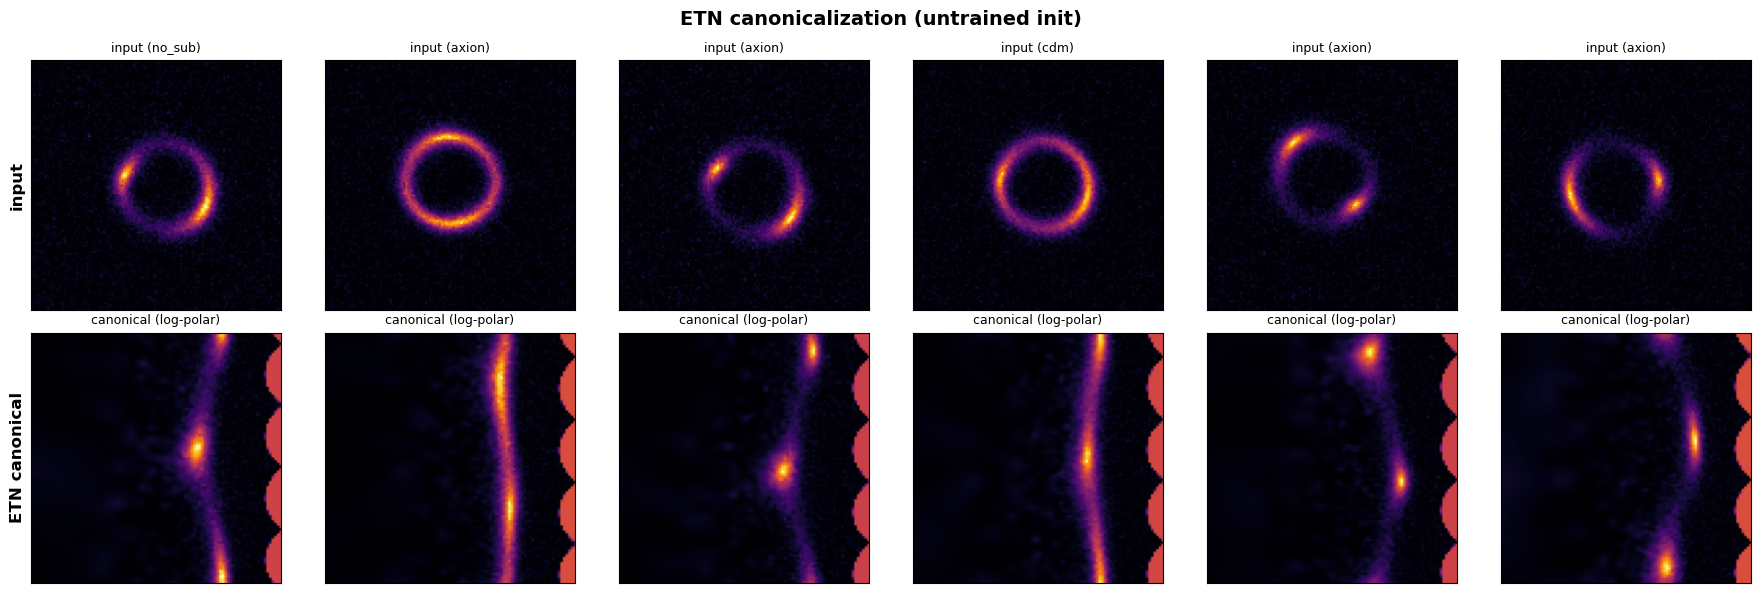

In [14]:
model.eval()
with torch.no_grad():
    xb, yb = next(iter(val_loader))
    xb = xb.to(device)
    x_canon = model.canon(xb[:6])

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i in range(6):
    axes[0, i].imshow(_denorm(xb[i]), cmap="inferno")
    axes[0, i].set_title(f"input ({CLASS_NAMES[int(yb[i])]})", fontsize=9)
    axes[1, i].imshow(_denorm(x_canon[i]), cmap="inferno")
    axes[1, i].set_title("canonical (log-polar)", fontsize=9)
    for r in (0, 1):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("input", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("ETN canonical", fontsize=12, fontweight="bold")
plt.suptitle("ETN canonicalization (untrained init)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "etn_qvit_canonicalization.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Training and evaluation utilities

In [15]:
def warmup_cosine_lambda(epoch: int, warmup_epochs: int, total_epochs: int) -> float:
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def train_model(model, criterion, optimizer, scheduler, loaders, sizes, num_epochs,
                patience=12, grad_clip=1.0, augmenter=None, dev=device):
    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    print(f"Training: {num_epochs} epochs, patience={patience}, grad_clip={grad_clip}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 36)
        for phase in ("train", "validation"):
            model.train() if phase == "train" else model.eval()
            running_loss = running_correct = running_total = 0.0
            loader = loaders[phase]
            pbar = tqdm(loader, desc=phase, total=len(loader))
            for inputs, labels in pbar:
                inputs = inputs.to(dev, non_blocking=True)
                labels = labels.to(dev, non_blocking=True)
                if phase == "train" and augmenter is not None:
                    inputs = augmenter(inputs)
                optimizer.zero_grad(set_to_none=True)
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = outputs.argmax(dim=1)
                    if phase == "train":
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                        optimizer.step()
                bs = inputs.size(0)
                running_loss += loss.item() * bs
                running_correct += (preds == labels).sum().item()
                running_total += bs
                pbar.set_postfix(loss=f"{loss.item():.4f}")

            epoch_loss = running_loss / max(1, running_total)
            epoch_acc = running_correct / max(1, running_total)
            print(f"{phase} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")
            if phase == "train":
                history["train_loss"].append(epoch_loss)
                history["train_acc"].append(epoch_acc)
                scheduler.step()
            else:
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    print(f"  >>> new best (val_acc={best_acc:.4f})")
                else:
                    epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping after {epoch + 1} epochs (no improvement {patience}).")
            break

    elapsed = time.time() - since
    print(f"\nTraining took {elapsed // 60:.0f}m {elapsed % 60:.0f}s. Best val acc: {best_acc:.4f}")
    model.load_state_dict(best_wts)
    return model, history


@torch.no_grad()
def evaluate_model(model, loader, dev=device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for inputs, labels in tqdm(loader, desc="test"):
        inputs = inputs.to(dev, non_blocking=True)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().numpy())
    all_probs_np = np.stack(all_probs, axis=0)
    accuracy = float(np.mean(np.array(all_preds) == np.array(all_labels)))
    try:
        roc_auc = float(roc_auc_score(all_labels, all_probs_np, multi_class="ovr", average="macro"))
    except Exception:
        roc_auc = 0.0
    return accuracy, all_preds, all_labels, all_probs_np, roc_auc


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
scheduler = lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda e: warmup_cosine_lambda(e, CFG["warmup_epochs"], CFG["num_epochs"]),
)
loaders = {"train": train_loader, "validation": val_loader}
sizes   = {"train": len(train_loader.dataset), "validation": len(val_loader.dataset)}
print(f"Sizes: {sizes}")


Sizes: {'train': 70021, 'validation': 17504}


## 9. Train

In [17]:
model, history = train_model(
    model=model, criterion=criterion, optimizer=optimizer, scheduler=scheduler,
    loaders=loaders, sizes=sizes, num_epochs=CFG["num_epochs"], patience=CFG["patience"],
    grad_clip=CFG["grad_clip"], augmenter=augmenter, dev=device,
)
torch.save(model.state_dict(), CHECKPOINT_PATH)
print(f"Saved: {CHECKPOINT_PATH}")


Training: 50 epochs, patience=12, grad_clip=1.0

Epoch 1/50
------------------------------------


train: 100%|██████████| 1095/1095 [05:24<00:00,  3.38it/s, loss=0.9184]


train Loss: 0.7670  Acc: 0.6289


validation: 100%|██████████| 274/274 [00:33<00:00,  8.06it/s, loss=0.6627]


validation Loss: 0.5349  Acc: 0.7602
  >>> new best (val_acc=0.7602)

Epoch 2/50
------------------------------------


...

validation Loss: 0.1211  Acc: 0.9556

Epoch 50/50
------------------------------------


train: 100%|██████████| 1095/1095 [05:22<00:00,  3.40it/s, loss=0.0053]


train Loss: 0.1242  Acc: 0.9557


validation: 100%|██████████| 274/274 [00:33<00:00,  8.10it/s, loss=0.1303]


validation Loss: 0.1214  Acc: 0.9550

Training took 297m 16s. Best val acc: 0.9558
Saved: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/etn_qvit_hybrid/model_1/checkpoints/best_etn_qvit_hybrid_model_1.pth


## 10. Evaluation

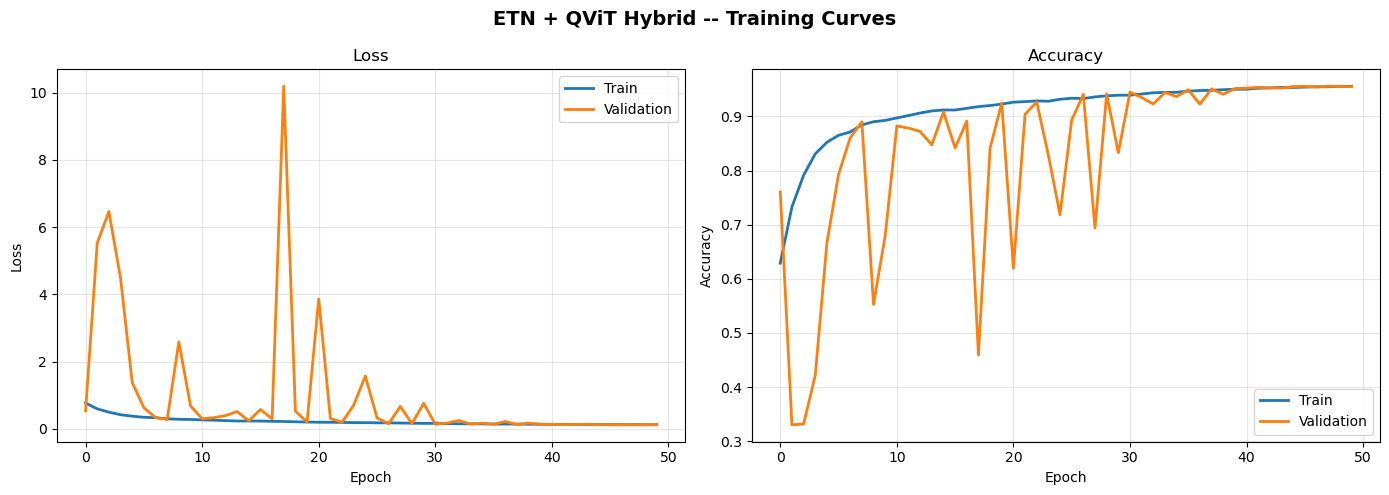

In [18]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["train_loss"], label="Train", linewidth=2)
    axes[0].plot(history["val_loss"],   label="Validation", linewidth=2)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history["train_acc"], label="Train", linewidth=2)
    axes[1].plot(history["val_acc"],   label="Validation", linewidth=2)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle("ETN + QViT Hybrid -- Training Curves", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "etn_qvit_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_confusion_matrix(test_labels, test_preds, class_names, test_acc):
    cm = confusion_matrix(test_labels, test_preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True"); axes[0].set_title("Counts")
    sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True"); axes[1].set_title("Percent")
    plt.suptitle(f"Test accuracy: {test_acc * 100:.2f}%", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "etn_qvit_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    return cm


def plot_roc_curves(test_labels, test_probs, class_names):
    n_classes = len(class_names)
    y_bin = label_binarize(test_labels, classes=list(range(n_classes)))
    y_scores = np.array(test_probs)
    fpr, tpr, roc_aucs = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_scores[:, i])
        roc_aucs[i] = auc(fpr[i], tpr[i])
    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_scores.ravel())
    roc_aucs["micro"] = auc(fpr["micro"], tpr["micro"])
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for i, cls in enumerate(class_names):
        axes[0].plot(fpr[i], tpr[i], linewidth=2, label=f"{cls} (AUC = {roc_aucs[i]:.4f})")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.05])
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC (per class)"); axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)
    axes[1].plot(fpr["micro"], tpr["micro"], linewidth=2, color="deeppink",
                 label=f"Micro-avg (AUC = {roc_aucs['micro']:.4f})")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC (micro-average)"); axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)
    plt.suptitle("ETN + QViT Hybrid -- ROC", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "etn_qvit_roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    return roc_aucs


plot_training_history(history)


test: 100%|██████████| 235/235 [00:29<00:00,  7.95it/s]



Test Accuracy: 95.44%
Test ROC AUC:  0.9943
Macro-F1:      0.9543

Classification report:
              precision    recall  f1-score   support

       axion     0.9482    0.9366    0.9423      5000
         cdm     0.9327    0.9320    0.9324      5000
      no_sub     0.9818    0.9946    0.9882      5000

    accuracy                         0.9544     15000
   macro avg     0.9542    0.9544    0.9543     15000
weighted avg     0.9542    0.9544    0.9543     15000



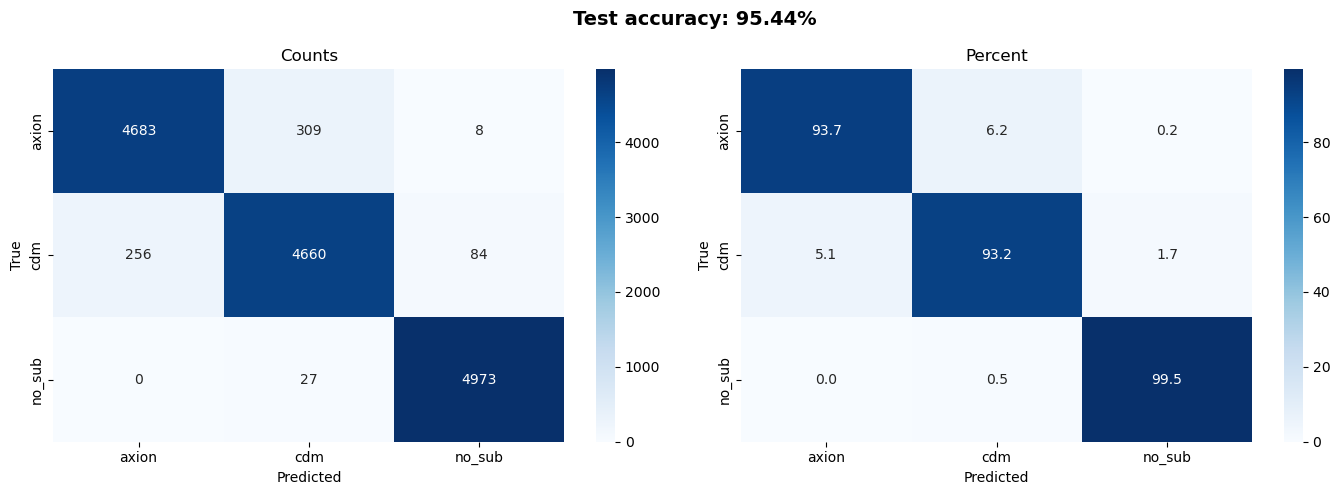

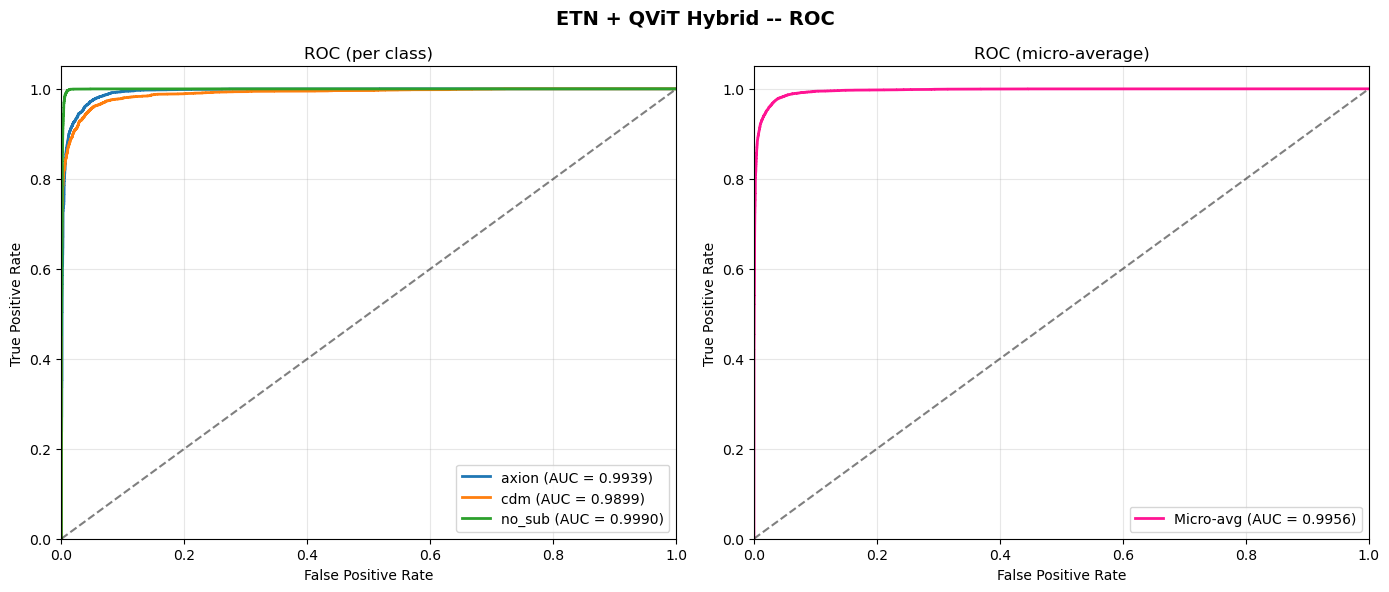

In [19]:
test_acc, test_preds, test_labels, test_probs, test_auc = evaluate_model(model, test_loader)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test ROC AUC:  {test_auc:.4f}")
print(f"Macro-F1:      {f1_score(test_labels, test_preds, average='macro'):.4f}")
print("\nClassification report:")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

plot_confusion_matrix(test_labels, test_preds, CLASS_NAMES, test_acc)
_ = plot_roc_curves(test_labels, test_probs, CLASS_NAMES)
